In [1]:
#%matplotlib qt
%matplotlib widget
import hyperspy.api as hs
import numpy as np
import matplotlib.pyplot as plt
import scipy.misc
import atomap.api as am

C:\Users\nagaa\AppData\Local\Temp\ipykernel_95828\3476736958.py:6: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


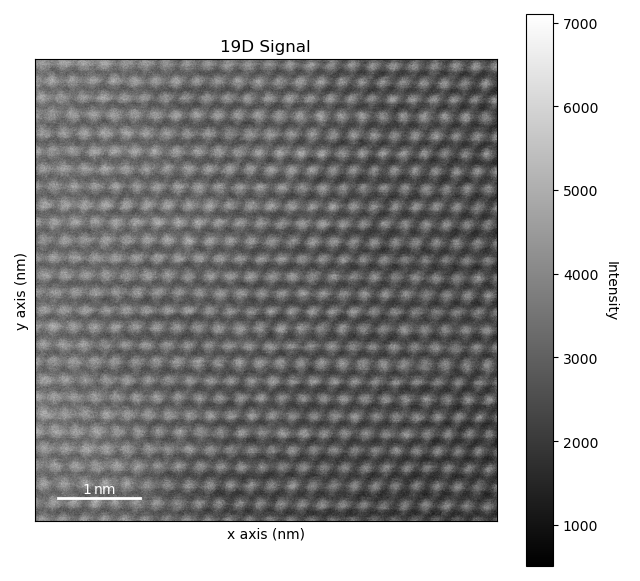

In [2]:
 s = hs.load('19D.dm3')
s.plot()
#flux_pattern = s.data

In [3]:
rectangular_roi = hs.roi.RectangularROI(left=0, right=15,top=0, bottom=15)

In [4]:
roi2D = rectangular_roi.interactive(s, color="blue") 
# roi1D = line_roi.interactive(im, color="yellow")
# roi0D = point_roi.interactive(im, color="red")

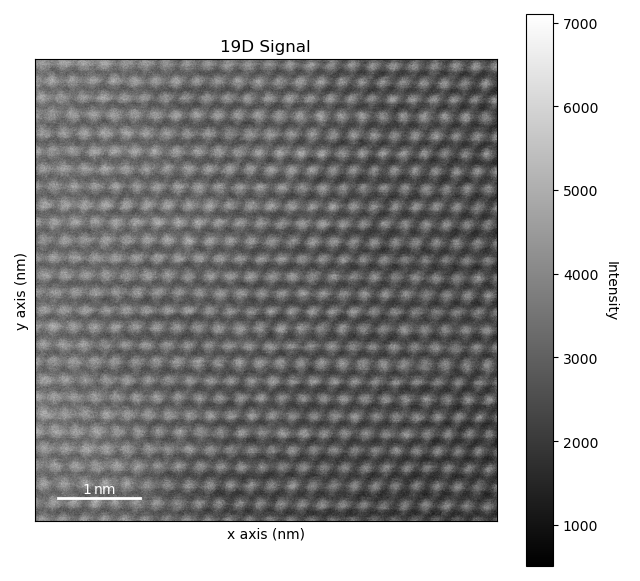

In [5]:
roi2D.plot()##########plot the cropped part

In [6]:
 s_peaks = am.get_feature_separation(roi2D, separation_range=(16,24), threshold_rel=0.1)
s_peaks.plot()

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

In [7]:
s.metadata

├── Acquisition_instrument
│   └── TEM
│       ├── acquisition_mode = STEM
│       ├── beam_current = 0.0
│       ├── beam_energy = 200.0
│       ├── camera_length = 80.0
│       ├── dwell_time = 1e-05
│       ├── magnification = 40000000.0
│       └── microscope = JEOL COM
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.3.0
│   │       ├── io_plugin = rsciio.digitalmicrograph
│   │       ├── operation = load
│   │       └── timestamp = 2026-06-08T09:18:57.566114+02:00
│   ├── date = 2021-01-26
│   ├── original_filename = 19D.dm3
│   ├── time = 15:28:13
│   └── title = 19D
└── Signal
    ├── Noise_properties
    │   └── Variance_linear_model
    │       ├── gain_factor = 1.0
    │       └── gain_offset = 0.0
    ├── quantity = Intensity
    └── signal_type =

In [8]:
atom_positions = am.get_atom_positions(roi2D, 23, threshold_rel=0.1)


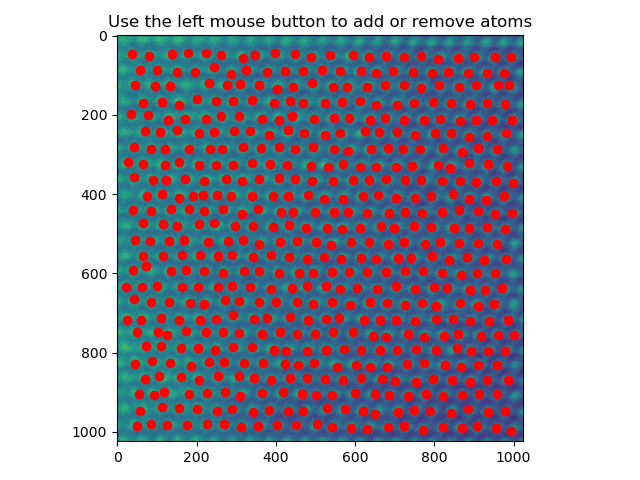

In [9]:
##################If there are any missing or extra atoms #add_atoms_with_gui()# can be used
atom_positions_new = am.add_atoms_with_gui(roi2D,atom_positions)

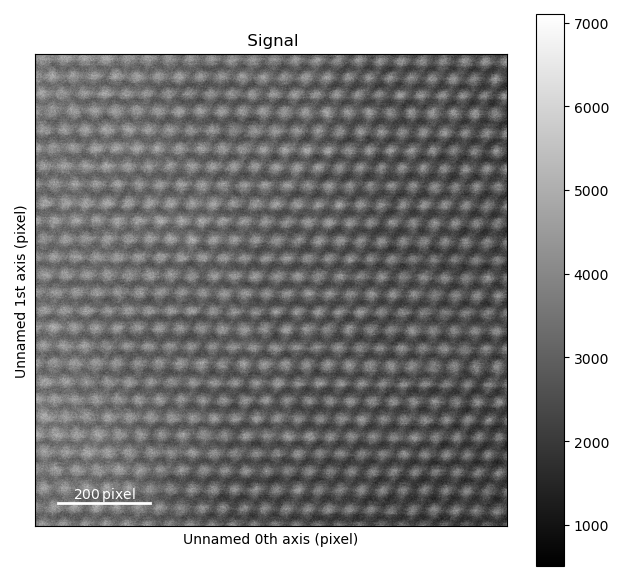

In [10]:
sublattice = am.Sublattice(atom_positions_new, roi2D.data)
sublattice.plot()

In [11]:
sublattice.find_nearest_neighbors()
sublattice.refine_atom_positions_using_center_of_mass()
sublattice.refine_atom_positions_using_2d_gaussian()

Center of mass:   0%|          | 0/535 [00:00<?, ?it/s]

Gaussian fitting:   0%|          | 0/535 [00:00<?, ?it/s]

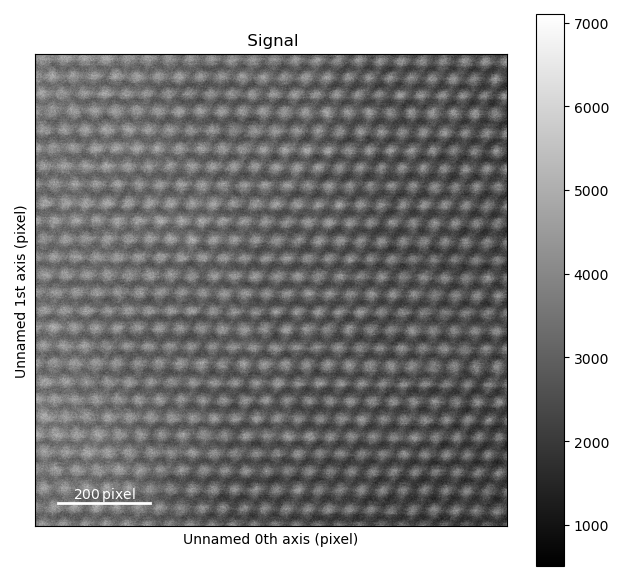

In [12]:
sublattice.plot()

In [13]:
#####Save the positions of atoms after Gaussian fitting#####
atom_position = sublattice.atom_positions
#type(atom_position)
np.savetxt("atom_position_19ADF_sublattice.csv", (atom_position), delimiter=',')

In [14]:
 sublattice.construct_zone_axes()
sublattice.plot_planes()

  0%|          | 0/535 [00:00<?, ?it/s]

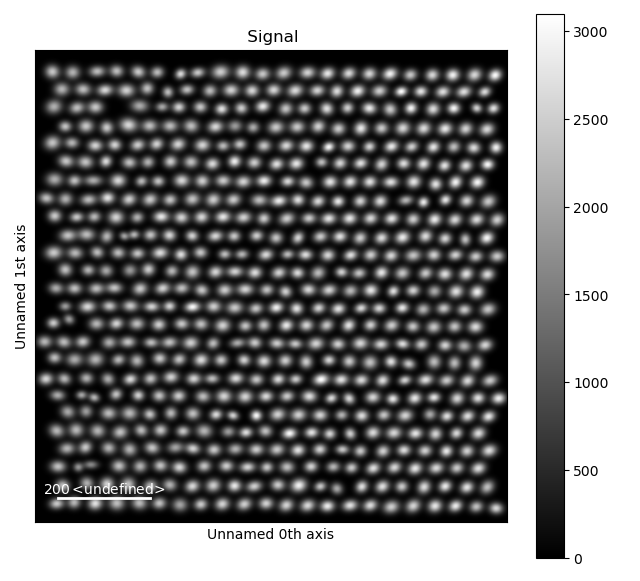

In [15]:
#get gaussian fitted image of the sublattice
model_image=sublattice.get_model_image(image_shape=None, sigma_quantile=5, show_progressbar=True)
model_image.plot()

In [16]:
###TO choose zone and plane this command must be used###
zone = sublattice.zones_axis_average_distances[1]
plane = sublattice.atom_planes_by_zone_vector[zone][0]

In [17]:
#returns x and y position with distance b/w atom to next atom in same plane
##there isn't much difference b.w distance_list_from_zone vector and distance_line_profile the former
#cannot be plotted but the later can be plotted
zone = sublattice.zones_axis_average_distances[1]
atom_distance = sublattice.get_atom_distance_list_from_zone_vector(zone)
print(atom_distance)

(array([962.14075412, 982.73764032, 916.04434783, 942.02455733,
       967.00197604, 987.89004682, 871.08356209, 894.35050805,
       919.06571102, 940.68241684, 964.49895896, 823.6447412 ,
       848.12134247, 874.36657906, 896.78205182, 919.28387242,
       944.97963074, 969.31069911, 990.56911669, 780.2844735 ,
       803.01654921, 827.32328341, 851.52647558, 874.10111973,
       898.09733944, 922.03888099, 944.92427246, 966.84482853,
       988.91566927, 734.31074505, 756.81545203, 782.14062783,
       805.41782202, 827.85374274, 853.81877349, 877.5935524 ,
       898.4953264 , 919.91822682, 942.4180393 , 966.38237827,
       688.57679791, 710.7938164 , 736.55828117, 760.49762774,
       784.50094644, 808.63206604, 830.15518568, 852.7738028 ,
       876.08748386, 898.50612663, 921.42138669, 944.97341362,
       968.57050647, 643.16675951, 664.75990585, 690.71914901,
       714.42275226, 736.83416589, 759.85985686, 786.09606319,
       810.32089822, 831.5579591 , 853.95435896, 874.9

In [18]:
np.savetxt("atomtoatom_distance_19ADF_zone1.csv", (atom_distance), delimiter=',')

In [19]:
zone = sublattice.zones_axis_average_distances[2]
plane = sublattice.atom_planes_by_zone_vector[zone][0]
monolayer_distance = sublattice.get_monolayer_distance_list_from_zone_vector(zone)

In [20]:
np.savetxt("Monolayer_distance_list_from_zone_vector_30ADF_zone_2.csv",(monolayer_distance),delimiter=',')

The mean monolayer separation and distance to the first                 
monolayer deviate with more than 10 %. Consider if there                 
are too many outliers


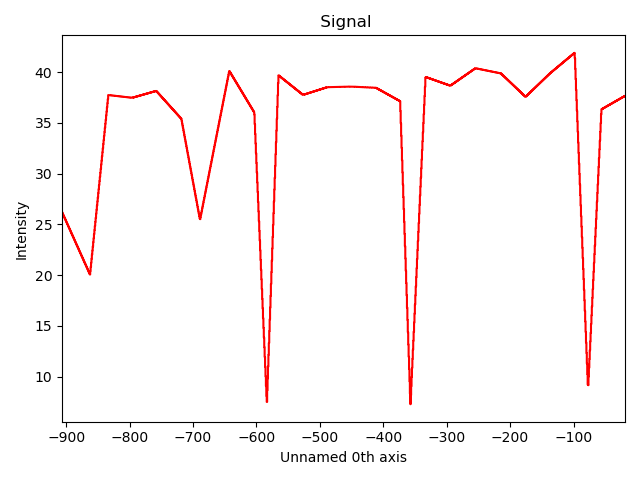

In [21]:
 s_monolayer_line = sublattice.get_monolayer_distance_line_profile(zone_vector=zone, atom_plane=plane)
s_monolayer_line.plot()

The mean monolayer separation and distance to the first                 
monolayer deviate with more than 10 %. Consider if there                 
are too many outliers


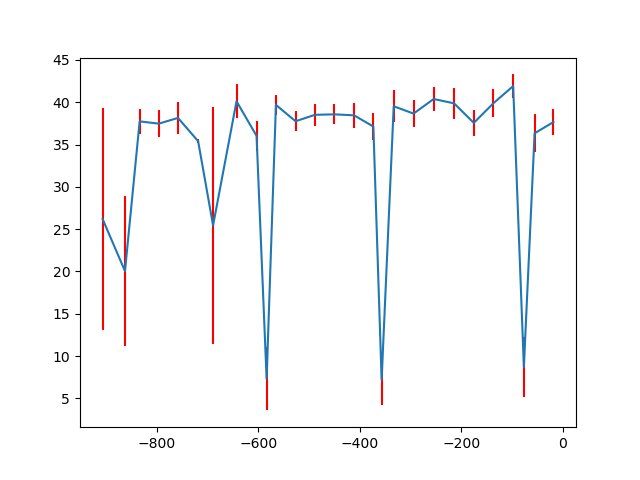

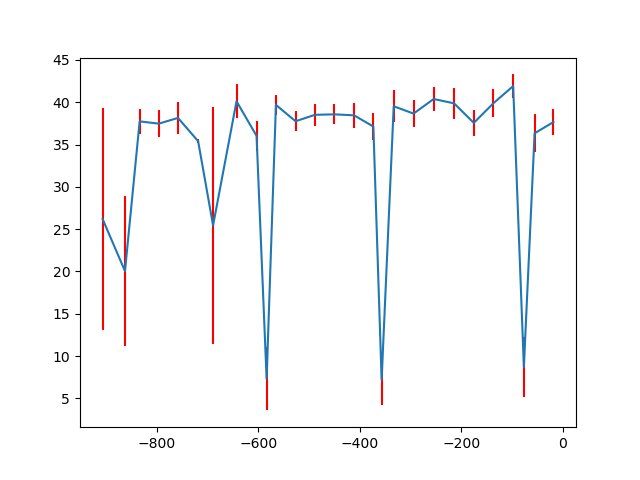

In [22]:
#Defn: Distance b.w an atom and the next monolayer in a sublattice
zone = sublattice.zones_axis_average_distances[2]
plane = sublattice.atom_planes_by_zone_vector[zone][0]
#plane = sublattice.atom_planes_by_zone_vector[zone][20] #change the selected plane, the profile doesn't change
distance_line_profile = sublattice.get_monolayer_distance_line_profile(zone, plane)



position = distance_line_profile.metadata.line_profile_data.x_list
distance_of_all_monolayers = distance_line_profile.metadata.line_profile_data.y_list
std = distance_line_profile.metadata.line_profile_data.std_list

fig, ax = plt.subplots()
_ = ax.errorbar(position,distance_of_all_monolayers,std,ecolor='red')
fig.show()


In [23]:
 np.savetxt("monolayer_distance_line_profile_30ADF_zone2.csv", (position,distance_of_all_monolayers,std), delimiter=',')

In [25]:
print(distance_of_all_monolayers*0.0087762)
distance =np.mean(distance_of_all_monolayers)*0.0087762
print(np.mean(distance_of_all_monolayers)*0.0087762 )

[0.23001113 0.17593221 0.33117825 0.32880443 0.33475102 0.31061054
 0.2232942  0.3520245  0.31609491 0.06413576 0.34826613 0.33130703
 0.33796878 0.33847341 0.33743301 0.32581703 0.06326482 0.34681602
 0.33926206 0.35435406 0.34988086 0.32962393 0.35000618 0.36776451
 0.07644481 0.31880226 0.3304514 ]
0.29306567650939613


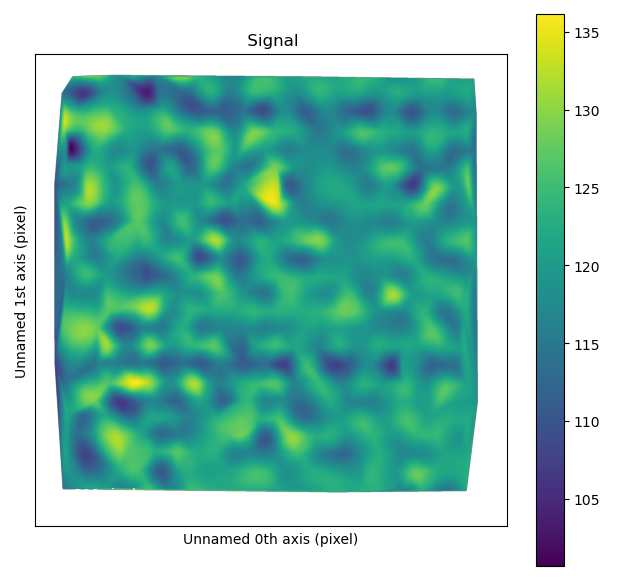

In [26]:
###############################################################
#To visualize the angle between the atoms, get_atom_angles_from_zone_vector() is used. 
#This function returns three lists: x- and y-coordinates of the atoms, and a list of the angle between two zone axes at each atom.
#get_property_map() is a very general function, and can plot a map of any property.
#Defn:Calculates for each atom in the sub lattice the angle between the atom, and the next atom in the atom planes in zone_vector0 and zone_vector1. Default will return the angles in radians.
###############################################################
z1 = sublattice.zones_axis_average_distances[0]
z2 = sublattice.zones_axis_average_distances[2]
x, y, a = sublattice.get_atom_angles_from_zone_vector(z1, z2, degrees=True)

s_angle = sublattice.get_property_map(x, y, a)
s_angle.plot(cmap='viridis')

In [27]:
np.savetxt("angle_19ADF_zone0 and zone2.csv", (x,y,a), delimiter=',')

Calculating Voronoi:   0%|          | 0/1048576 [00:00<?, ?it/s]

Integrating:   0%|          | 0/535 [00:00<?, ?it/s]

Building intensity map:   0%|          | 0/1048576 [00:00<?, ?it/s]

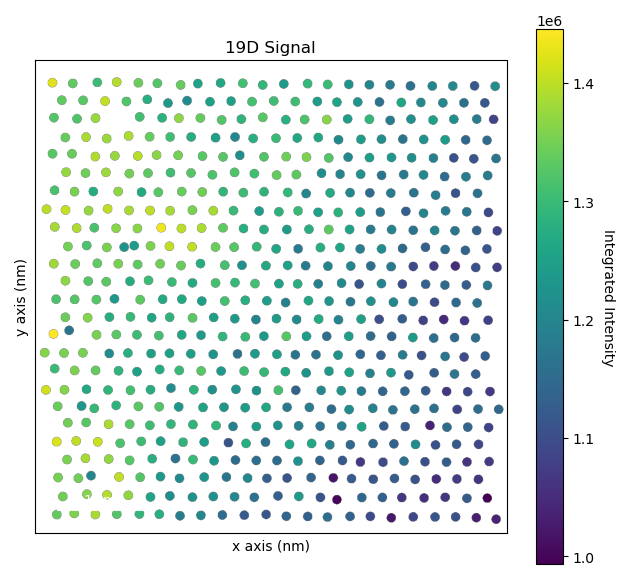

In [28]:
##########Get intensity of each atomic column##########
(integrated_s, intensityRecord, pointRecord) = am.integrate(
    roi2D, sublattice.x_position, sublattice.y_position, method='Voronoi', max_radius=10)
intensityRecord.plot(cmap='viridis')

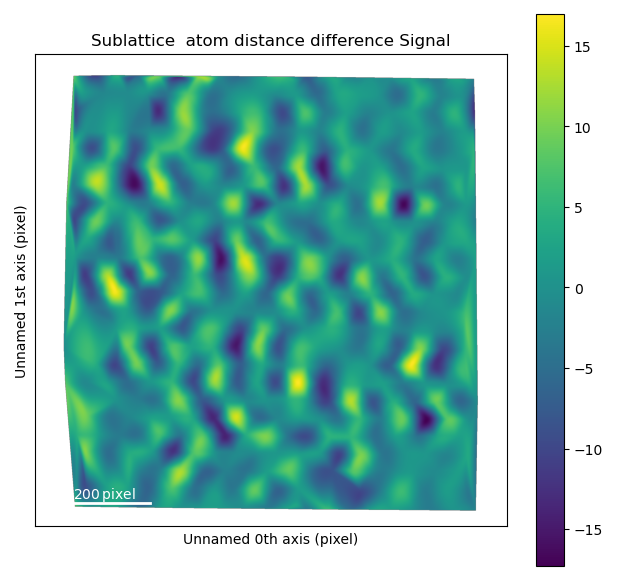

In [29]:
##########Atom distance difference map############
zone = sublattice.zones_axis_average_distances[2]
s_dd = sublattice.get_atom_distance_difference_map([zone])
s_dd.plot(cmap='viridis')
#sublattice.plot_planes(image=sublattice.image)

The mean monolayer separation and distance to the first                 
monolayer deviate with more than 10 %. Consider if there                 
are too many outliers


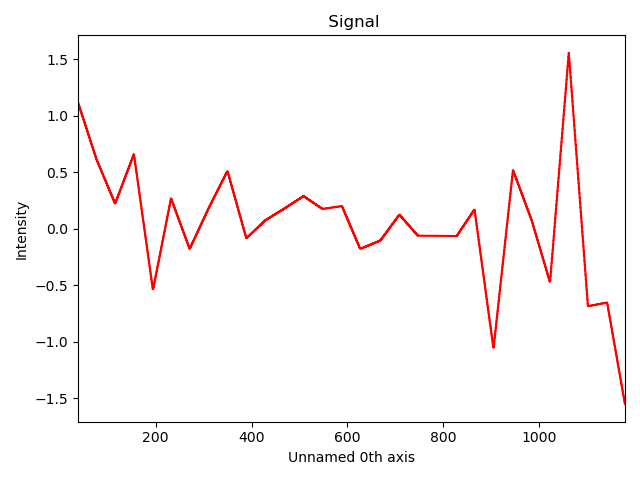

In [30]:
##########Atom distance difference line profile##########
zone = sublattice.zones_axis_average_distances[0]
plane = sublattice.atom_planes_by_zone_vector[zone][0]
s_dd_line = sublattice.get_atom_distance_difference_line_profile(zone, plane)
s_dd_line.plot()

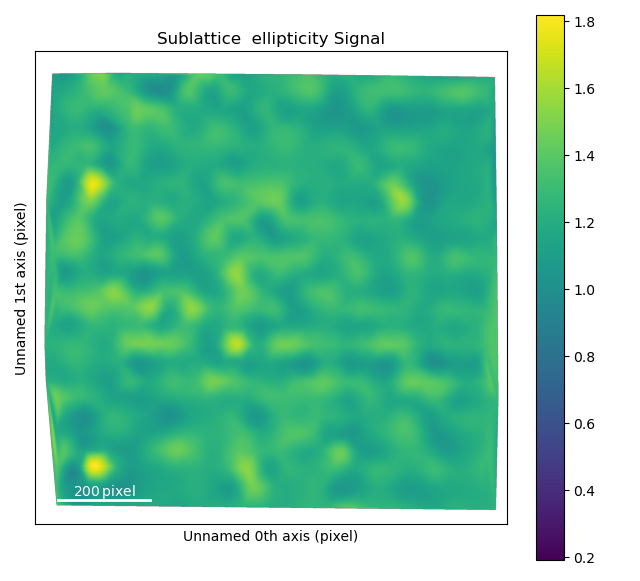

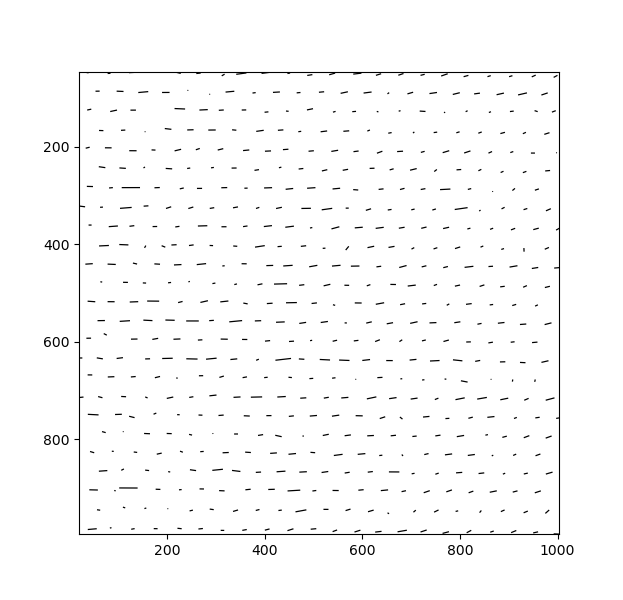

In [31]:
########################################################################
#Ellipticity map and vector plot
#########################################################################
sublattice.plot_ellipticity_map(cmap='viridis')#(, vmin=0.95, vmax=1.3)#

sublattice.plot_ellipticity_vectors()


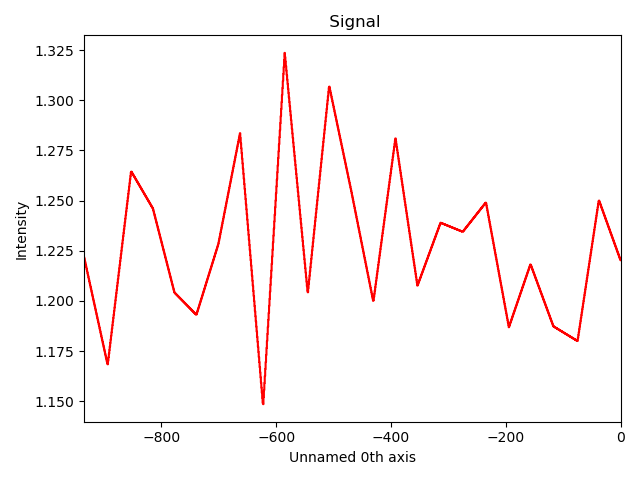

In [32]:
###########Ellipticity line profile#############
zone = sublattice.zones_axis_average_distances[2]
plane = sublattice.atom_planes_by_zone_vector[zone][0]
s_elli_line = sublattice.get_ellipticity_line_profile(plane)
s_elli_line.plot()

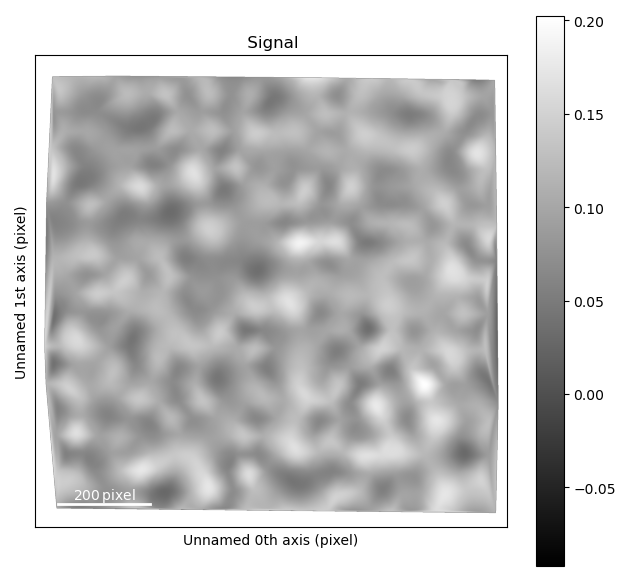

C:\Users\nagaa\HyperSpy-bundle\Lib\site-packages\hyperspy\drawing\utils.py:171: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(**kwargs)


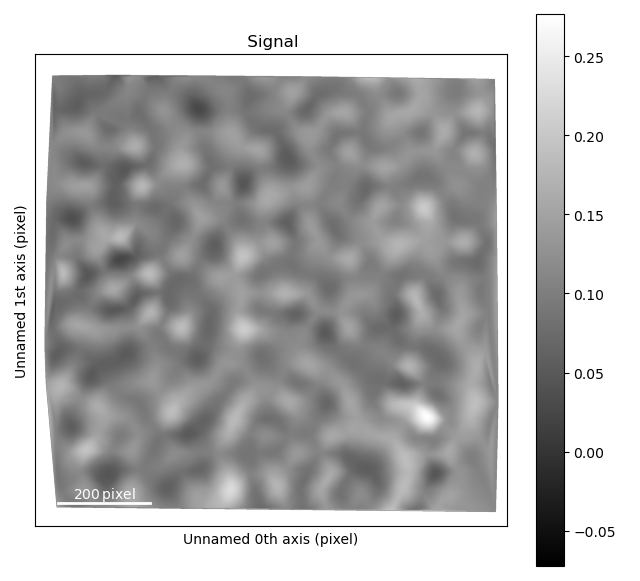

In [33]:
######Scanning distortion estimation###########

s_x, s_y, avg_x, avg_y =sublattice.estimate_local_scanning_distortion(image=None, radius=6, edge_skip=2)
 
s_x.plot()
s_y.plot()

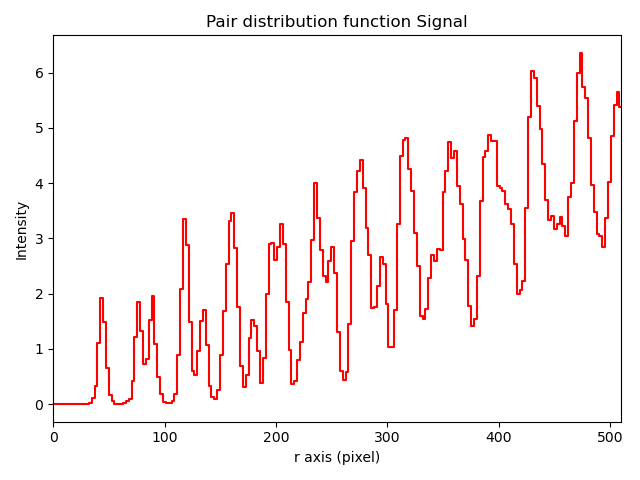

In [34]:
#######Pair distribution function########
s_pdf = sublattice.pair_distribution_function()
s_pdf.plot()